# Import Variables and Load Packages

In [1]:
import uproot
#print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle
import matplotlib as mpl

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/H-KPMTcalibration/HKPMTcalibration/LIGen395_Pos0_DROff_hits_flat (1).root')

print(f['photonTree;2'].keys())
print(f['hitsTree'].keys())


f.keys()


['event', 'subevent', 'tubeId', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ', 'endDirX', 'endDirY', 'endDirZ', 'normX', 'normY', 'normZ']
['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']


['photonTree;2', 'photonTree;1', 'hitsTree;1']

## Load Variables

In [2]:
photon = ['event', 'subevent', 'tubeId', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ', 'endDirX', 'endDirY', 'endDirZ', 'normX', 'normY', 'normZ']

hits = ['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

vars = {}
vars2 = {}
vars.update(f["photonTree"].arrays(photon, library="np"))
vars2.update(f["hitsTree"].arrays(hits, library="np"))

for key, value in vars.items():
    print(f"{key}: {len(value)}")

for key, value in vars2.items():
    print(f"{key}: {len(value)}")
    
for col in tqdm(vars):
    vars[col] = vars[col].tolist()
    
for col in tqdm(vars2):
    vars2[col] = vars2[col].tolist()

ph_df = pd.DataFrame(vars)
hit_df = pd.DataFrame(vars2)

ph_df.shape, hit_df.shape

# print highest event value for ph_df
print("photon event max for hit_df: ", hit_df['event'].max())

event: 938651
subevent: 938651
tubeId: 938651
startX: 938651
startY: 938651
startZ: 938651
endX: 938651
endY: 938651
endZ: 938651
endDirX: 938651
endDirY: 938651
endDirZ: 938651
normX: 938651
normY: 938651
normZ: 938651
event: 839337
subevent: 839337
pmt_id: 839337
charge: 839337
time: 839337
posX: 839337
posY: 839337
posZ: 839337


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

photon event max for hit_df:  9999


In [3]:
#ph_df[ph_df["event"] == 9999]
#hit_df[hit_df["event"] == 9999]

#small_y_df = ph_df[abs(ph_df["startY"])<.0001]

moved_df = ph_df[
    (ph_df["startX"] != ph_df["endX"]) &
    (ph_df["startY"] != ph_df["endY"]) &
    (ph_df["startZ"] != ph_df["endZ"])
]

near_source_df = ph_df[ph_df["startX"]<40000]

moved_and_near_source_df = moved_df[abs(moved_df["startX"])<40000]

print(f'number of moved photons (start x,y,z != end x,y,z): {len(moved_df)}')
print(f'number of photons near source (startX<4000): {len(near_source_df)}')
print(f'number of photons that move and have startX<4000: {len(moved_and_near_source_df)}')

# can one photon hit on two pmts?

number of moved photons (start x,y,z != end x,y,z): 938651
number of photons near source (startX<4000): 938651
number of photons that move and have startX<4000: 938651


In [4]:
# some global variables

radius = 3242.76611328125
height = 2*3296.47119140625

xmin = -3242.76611328125
xmax = 3242.76611328125
ymin = -3242.76611328125
ymax = 3242.76611328125
zmin = -3296.47119140625
zmax = 3296.47119140625

# can one photon hit on two pmts?

# make a pmt dictionary with pmt_type 

pmt_dict = {
    row.pmt_id: (row.posX, row.posY, row.posZ)
    for row in hit_df[['pmt_id', 'posX', 'posY', 'posZ']]
        .drop_duplicates(subset='pmt_id')
        .itertuples(index=False)
}

for pmt in pmt_dict:
    if np.isclose(pmt_dict[pmt][2], 3296.47119140625):
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'top')
    elif np.isclose(pmt_dict[pmt][2], -3296.47119140625):
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'bottom')
    else:
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'barrel')

print(pmt_dict)
    
pmt_dict[1234]

pmt_normals = {}
for row in hit_df[['pmt_id', 'posX', 'posY', 'posZ']].drop_duplicates(subset='pmt_id').itertuples(index=False):
    pmt_id, pmt_x, pmt_y, pmt_z = row.pmt_id, row.posX, row.posY, row.posZ

    # define normal vector
    if pmt_z == 3296.47119140625:
        normal_vector = np.array([0, 0, -1])
    elif pmt_z == -3296.47119140625:
        normal_vector = np.array([0, 0, 1])
    else:
        normal_vector = np.array([-pmt_x/radius, -pmt_y/radius, 0])

    # normalize
    normal_vector = normal_vector / np.linalg.norm(normal_vector)

    # store in separate dict
    pmt_normals[pmt_id] = normal_vector
    


{13008: (3241.222900390625, 106.10665130615234, -2543.196044921875, 'barrel'), 9554: (3233.509521484375, 247.38580322265625, -2401.827880859375, 'barrel'), 19511: (2400.39990234375, -141.1999969482422, -3296.47119140625, 'bottom'), 19444: (2259.199951171875, 282.3999938964844, -3296.47119140625, 'bottom'), 19474: (2329.800048828125, 635.4000244140625, -3296.47119140625, 'bottom'), 19346: (2047.4000244140625, -494.20001220703125, -3296.47119140625, 'bottom'), 19309: (1976.800048828125, -282.3999938964844, -3296.47119140625, 'bottom'), 19310: (1976.800048828125, -423.6000061035156, -3296.47119140625, 'bottom'), 18999: (1412.0, 141.1999969482422, -3296.47119140625, 'bottom'), 19158: (1694.4000244140625, 141.1999969482422, -3296.47119140625, 'bottom'), 19088: (1553.199951171875, -1129.5999755859375, -3296.47119140625, 'bottom'), 18790: (1059.0, 70.5999984741211, -3296.47119140625, 'bottom'), 19445: (2259.199951171875, 141.1999969482422, -3296.47119140625, 'bottom'), 18796: (1059.0, -776.59

In [5]:
top10_id = ph_df["tubeId"].value_counts().head(10)

for pmt_id, freq in top10_id.items():
    print(f"pmt_id {pmt_id}: {freq}")
    

pmt_id 13007: 1108
pmt_id 19379: 1037
pmt_id 19306: 1031
pmt_id 19308: 1029
pmt_id 19272: 1016
pmt_id 19270: 1005
pmt_id 19343: 983
pmt_id 19234: 979
pmt_id 19307: 970
pmt_id 19342: 969


296
26.921161530426463
plotted at (np.float64(-21.236053194390692), np.float64(14.366113281249909)) 
26.92115229663431
plotted at (np.float64(-8.562254273325108), np.float64(20.509082031249818)) 
26.921210750354902
plotted at (np.float64(-1.6203145437955444), np.float64(21.168066406249636)) 
26.921196906480503
plotted at (np.float64(5.08968167041312), np.float64(9.741503906249818)) 
26.92113353469764
plotted at (np.float64(-11.46025901401252), np.float64(23.106738281249818)) 
26.92121045051397
plotted at (np.float64(-11.890969253843437), np.float64(16.68603515625)) 
26.92113353469764
plotted at (np.float64(-11.46025901401252), np.float64(23.106738281249818)) 
26.92113353469764
plotted at (np.float64(-11.46025901401252), np.float64(23.106738281249818)) 
26.92113353469764
plotted at (np.float64(-11.46025901401252), np.float64(23.106738281249818)) 
26.92113353469764
plotted at (np.float64(-11.46025901401252), np.float64(23.106738281249818)) 
26.921060571185773
plotted at (np.float64(-17.4

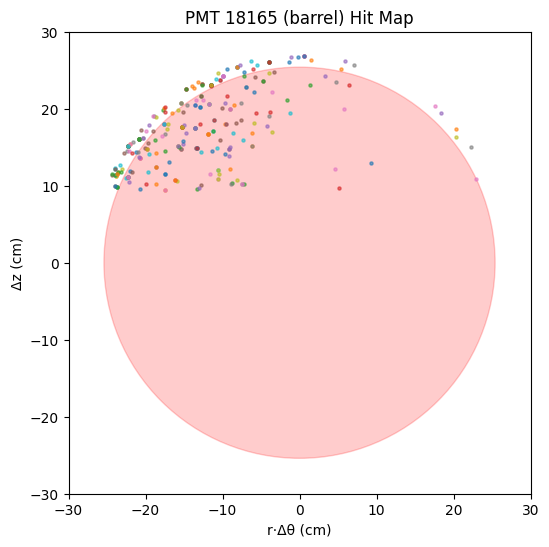

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def make_display_single_pmt(pmt_id):    
    
    # Filter hits for this PMT
    one_pmt_df = hit_df[hit_df["pmt_id"] == pmt_id]
    
    # If photons are already matched, otherwise you probably want one_pmt_df
    #y_df = ph_df[ph_df["closest_pmt"]==pmt_id]
                
    y_df = ph_df[ph_df["tubeId"] == pmt_id]
           
    print(y_df.shape[0])

    # End points (scaled to cm)
    x_ends = y_df["endX"].values * 0.1
    y_ends = y_df["endY"].values * 0.1
    z_ends = y_df["endZ"].values * 0.1
        
    # PMT position
    pmt_x, pmt_y, pmt_z = pmt_dict[pmt_id][:3]
    
    # Classify PMT type
    if np.isclose(pmt_z, 3296.47119140625, atol=1):
        pmt_type = 'endcap'
    else:
        pmt_type = 'barrel'
    
    fig, ax = plt.subplots(figsize=(6,6))

    # PMT face
    circle = patches.Circle((0, 0), radius=25.4, color='r', fill=True, alpha=0.2)
    ax.add_patch(circle)

    # --- Barrel reference angle ---
    if pmt_type == 'barrel':
        phi0 = np.arctan2(pmt_y, pmt_x)
        R = np.sqrt(pmt_x**2 + pmt_y**2)

    # --- Loop over hits ---
    for xe, ye, ze in zip(x_ends, y_ends, z_ends):

        # Only keep hits close to PMT face
        print(np.linalg.norm([xe-pmt_x, ye-pmt_y, ze-pmt_z]))
        if np.linalg.norm([xe - pmt_x, ye - pmt_y, ze - pmt_z]) < 300:

            dx = xe - pmt_x
            dy = ye - pmt_y
            dz = ze - pmt_z

            if pmt_type == 'barrel':
                # Cylindrical projection

                phi = np.arctan2(ye, xe)
                dphi = phi - phi0

                # Wrap angle to [-pi, pi]
                dphi = (dphi + np.pi) % (2*np.pi) - np.pi

                x_proj = R * dphi      # arc length (r * theta)
                y_proj = dz            # vertical

            else:
                # Endcap: flat projection
                x_proj = dx
                y_proj = dy

            ax.scatter(x_proj, y_proj, s=5, alpha=0.6)
            print(f"plotted at {x_proj, y_proj} ")

    # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)

    if pmt_type == 'barrel':
        ax.set_xlabel("r·Δθ (cm)")
        ax.set_ylabel("Δz (cm)")
    else:
        ax.set_xlabel("Δx (cm)")
        ax.set_ylabel("Δy (cm)")

    ax.set_title(f"PMT {pmt_id} ({pmt_type}) Hit Map")

    plt.show()


# Example
make_display_single_pmt(18165)

296 photons
296 photons after cut


/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


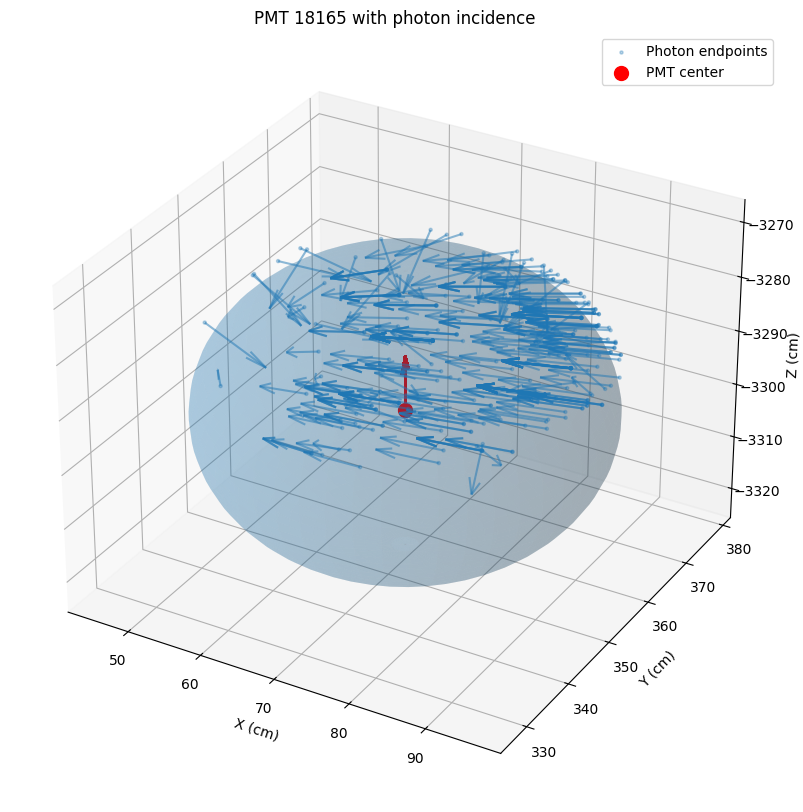

In [7]:
# 3d option of above

import matplotlib.pyplot as plt
import numpy as np

def plot_single_pmt_3d(pmt_id, max_dist=27, arrow_scale=10):
    """
    3D plot of photon endpoints + direction vectors + PMT as transparent sphere.
    """

    # --- Select photons ---
    y_df = ph_df[ph_df["tubeId"] == pmt_id]
    print(f"{y_df.shape[0]} photons")

    # --- Photon endpoints (cm) ---
    x = y_df["endX"].values * 0.1
    y = y_df["endY"].values * 0.1
    z = y_df["endZ"].values * 0.1

    # --- Direction vectors ---
    dx = y_df["endDirX"].values
    dy = y_df["endDirY"].values
    dz = y_df["endDirZ"].values
    
    norm_xs = y_df["normX"].values
    norm_ys = y_df["normY"].values
    norm_zs = y_df["normZ"].values

    # --- PMT position ---
    pmt_x, pmt_y, pmt_z = pmt_dict[pmt_id][:3]

    # --- Distance cut (optional) ---
    dist = np.sqrt((x - pmt_x)**2 + (y - pmt_y)**2 + (z - pmt_z)**2)
    mask = dist < max_dist

    x, y, z = x[mask], y[mask], z[mask]
    dx, dy, dz = dx[mask], dy[mask], dz[mask]

    print(f"{len(x)} photons after cut")

    # --- Subsample for performance (optional) ---
    if len(x) > 3000:
        idx = np.random.choice(len(x), 3000, replace=False)
        x, y, z = x[idx], y[idx], z[idx]
        dx, dy, dz = dx[idx], dy[idx], dz[idx]

    # --- Plot ---
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')

    # --- PMT sphere ---
    r = 25.4  # cm

    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)

    xs = pmt_x + r * np.outer(np.cos(u), np.sin(v))
    ys = pmt_y + r * np.outer(np.sin(u), np.sin(v))
    zs = pmt_z + r * np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(xs, ys, zs, alpha=0.2)

    # --- Photon endpoints ---
    ax.scatter(x, y, z, s=5, alpha=0.3, label="Photon endpoints")

    # --- Direction arrows ---
    ax.quiver(
        x, y, z,
        dx, dy, dz,
        length=arrow_scale,
        normalize=True,
        alpha=0.5
    )
    
    ax.quiver(
        pmt_x, pmt_y, pmt_z,
        norm_xs, norm_ys, norm_zs,
        length=arrow_scale,
         color='red',
         normalize=True,
         alpha=0.5
    )

    # --- PMT center ---
    ax.scatter(pmt_x, pmt_y, pmt_z, color='red', s=100, label="PMT center")

    # --- Labels ---
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_zlabel("Z (cm)")
    ax.set_title(f"PMT {pmt_id} with photon incidence")

    ax.legend()
    plt.show()
    
    
plot_single_pmt_3d(18165)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def get_pmt_normal(pmt_id):
    """Return the normal vector for a PMT, with top/bottom special cases."""
    x, y, z, _ = pmt_dict[pmt_id]
    
    # Top / bottom check
    if np.isclose(z, 3296.47119140625):
        return np.array([0, 0, -1])
    elif np.isclose(z, -3296.47119140625):
        return np.array([0, 0, 1])
    
    # Otherwise, use the stored normal
    n = np.array(pmt_normals[pmt_id])
    return n / np.linalg.norm(n)

def pmt_2d_projection(pmt_ids, pmt_info, size, info_label, dot_size, show_vals=False):
    fig, (ax_barrel, ax_persp) = plt.subplots(1, 2, figsize=(18, 10))
    
    # some vars that are globally relevant
    center_pmt = pmt_ids[0]
    n = get_pmt_normal(center_pmt)
    cent_x, cent_y, cent_z, _ = pmt_dict[center_pmt]
    cent_pos = np.array([cent_x, cent_y, cent_z])  # Only the numeric part!

    
    
    # full barrel plot
    rect = Rectangle((-np.pi*radius, -height/2), 2*np.pi*radius, height, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(rect)
    top_circle = Circle((0, height/2 + radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(top_circle)
    bottom_circle = Circle((0, (-height/2)-radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(bottom_circle)
    
    
    ax_barrel.set_xlim(-1.2*np.pi*radius, 1.2*np.pi*radius)
    ax_barrel.set_ylim(-1.2*radius - height, 1.2*radius + height)
    ax_barrel.set_aspect('equal')
    ax_barrel.set_xlabel("Distance around barrel (cm)")
    ax_barrel.set_ylabel("Height (cm)")
    ax_barrel.set_title("Full Cylinder View")

    # plot center on barrel plot, make sure to check if on top/bottom
    if np.isclose(cent_z, 3296.47119140625):
        # Top PMT
        star_x = cent_x          # x-coordinate in barrel plot
        star_z = cent_y + radius + height/2  # place on top circle
    elif np.isclose(cent_z, -3296.47119140625):
        # Bottom PMT
        star_x = cent_x
        star_z = cent_y - radius - height/2  # place on bottom circle
    else:
        # Regular PMT
        star_x = cent_x * np.pi
        star_z = cent_z

    # Plot center PMT as a star
    ax_barrel.scatter(
        star_x, star_z,
        marker='*',
        color='#FF7F0E',  # bright orange
        s=300,
        edgecolors='k',
        label=f'Center PMT: {center_pmt}'
    )
    
    ax_barrel.legend(loc='upper right')
    
    # red square highlighting region of interest
    
    center_pmt = pmt_ids[0]
    n = get_pmt_normal(center_pmt)
    cent_pos = np.array(pmt_dict[center_pmt])
    # select whether we are working with top/bottom once again
    if np.allclose(n, [0, 0, -1]):
        # top
        roi = Rectangle(
            (cent_pos[0] - size/2, (cent_pos[1] + radius + height/2) - size/2),
            size, size,
            facecolor='red', alpha=0.2
        )
        ax_barrel.add_patch(roi)
        
    elif np.allclose(n, [0, 0, 1]):
        # bottom
        roi = Rectangle(
            (cent_pos[0] - size/2, (cent_pos[1] - radius - height/2) - size/2),
            size, size,
            facecolor='red', alpha=0.2
        )
        ax_barrel.add_patch(roi)
        
    else:
        # barrel
        roi = Rectangle(
            (cent_pos[0]*np.pi - size/2, cent_pos[2] - size/2),
            size, size,
            facecolor='red', alpha=0.2
        )
        ax_barrel.add_patch(roi)
    
    # PMT perspective plot
    
    # create orthonormal basis for projection
    if np.allclose(n, [0,0,1]) or np.allclose(n, [0,0,-1]):
        # Vertical normal: use x and y axes
        u = np.array([1,0,0])
        v = np.array([0,1,0])
    else:
        # General case
        u = np.cross([0,0,1], n)  # u is perpendicular to both z and n (phi hat)
        u /= np.linalg.norm(u)      # normalize, just in case
        v = np.cross(n, u)          # v is perpendicular to n and u, (should be z hat)
    
    info_array = np.array(pmt_info, dtype=float)
    center_value = info_array[0]

    # Avoid division by zero
    if center_value == 0:
        center_value = 1.0

    # Normalize relative to center
    info_array = info_array / center_value

    # Robust normalization centered at 1
    vmin = info_array.min()
    vmax = info_array.max()

    # Ensure valid ordering for TwoSlopeNorm
    if vmin == vmax:
        vmin -= 1e-6
        vmax += 1e-6

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=(vmin+vmax)/2, vmax=vmax)

    # Colormap
    cmap = cm.get_cmap('viridis')

    for i, (pmt_id, info) in enumerate(zip(pmt_ids, info_array)):
        pos = np.array(pmt_dict[pmt_id]) - cent_pos
        x_proj = np.dot(pos, u)
        y_proj = np.dot(pos, v)

        color = cmap(norm(info))

        sc = ax_persp.scatter(
            x_proj, y_proj,
            c=[color],
            s=dot_size,
            label=info_label if i == 0 else None,
            zorder=2
        )

        if show_vals:
            text_color = 'white' if norm(info) > 0.5 else 'black'
            ax_persp.text(
                x_proj, y_proj,
                f"{info:.2f}",
                ha='center', va='center',
                fontsize=8,
                color=text_color,
                zorder=3
            )
        #print(f"PMT {pmt_id}: info={info}, projected=({x_proj:.1f},{y_proj:.1f}), marker_size={marker_size:.1f}")
    legend_dot = Line2D(
        [0], [0], 
        marker='o', 
        color='w',                  # line itself invisible
        markerfacecolor='#21908C',  # fill color of dot
        markeredgecolor='#21908C',  # optional: edge color
        markersize=8, 
        label=info_label)
    ax_persp.legend(handles=[legend_dot], loc='upper right')
    
    ax_persp.set_xlim(-size/2, size/2)
    ax_persp.set_ylim(-size/2, size/2)
    ax_persp.set_xlabel("Distance Projected Along u (cm)")
    ax_persp.set_ylabel("Distance Projected Along v (cm)")
    ax_persp.set_aspect('equal')
    ax_persp.set_title("Perspective View Along PMT Normal")
    ax_persp.tick_params(axis='both', which='both', labelsize=10)
    plt.colorbar(sc, ax=ax_persp, label='Relative Charge')
    fig.tight_layout()
    plt.show()
    

def get_hit_count(pmt_id):
    return hit_df[hit_df['pmt_id'] == pmt_id].shape[0]

def get_photon_count(pmt_id):
    return ph_df[ph_df['tubeId'] == pmt_id].shape[0]

charge_by_pmt = hit_df.groupby('pmt_id')['charge'].sum()

def get_charge(pmt_id):
    return charge_by_pmt.get(pmt_id, 0.0)


pmt_lookup = (
    hit_df[['pmt_id', 'posX', 'posY', 'posZ']]
    .drop_duplicates(subset='pmt_id')
    .set_index('pmt_id')
)

all_pmt_ids = pmt_lookup.index.values
positions = pmt_lookup[['posX','posY','posZ']].values

hit_counts = hit_df['pmt_id'].value_counts()

def get_nearest_pmts(pmt_id, k):
    if pmt_id not in pmt_lookup.index:
        raise ValueError(f"PMT {pmt_id} not found")

    target = pmt_lookup.loc[pmt_id].values

    # compute distances
    dists = np.linalg.norm(positions - target, axis=1)
    mask = all_pmt_ids != pmt_id

    nearest_idx = np.argsort(dists[mask])[:k]
    nearest_pmts = all_pmt_ids[mask][nearest_idx]

    return nearest_pmts

hit_counts = hit_df['pmt_id'].value_counts()


#plot_pmts_side_by_side(pmt_ids, pmt_info, 6000, "Relative Charge", 20)

#pmt_dict[18300]

# very generalizable: put in center pmt, number of neighbors, function for the value you would like to compute, size of region of interest
# always projected along normal vector of the designated pmt
# if we are parallel to the xy plane, then u is x hat and v is y hat. if we are on the barrel, u is positive phi hat and v is z hat

TypeError: unsupported operand type(s) for -: 'numpy.str_' and 'float'

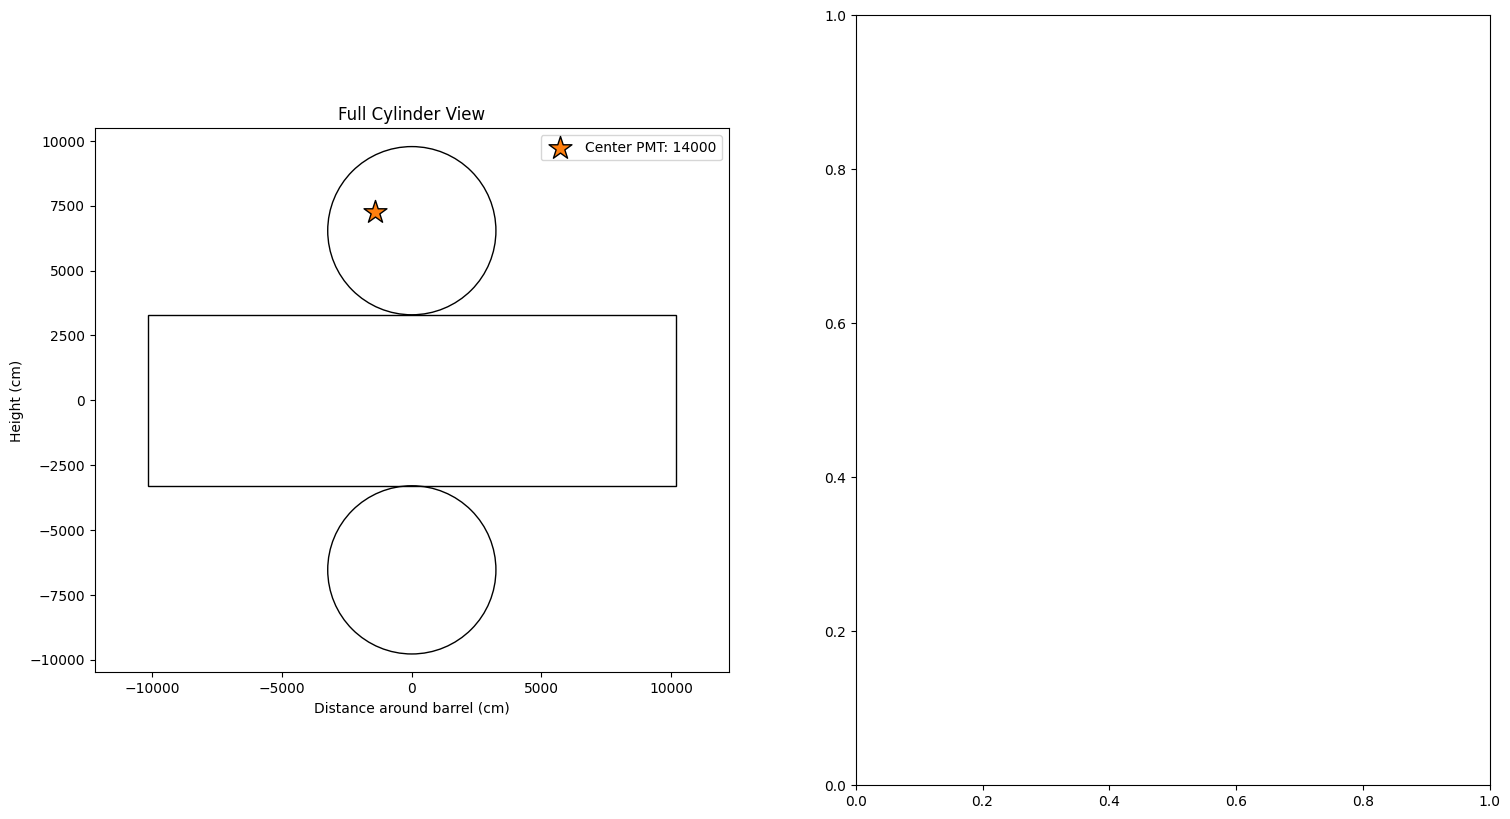

In [21]:
center_pmt = 14000

num = 1000

pmt_hits = hit_df['pmt_id'].value_counts()

pmt_incident_photon_counts = ph_df['tubeId'].value_counts()

pmt_nn_ids = get_nearest_pmts(center_pmt, num)

pmt_ids = np.concatenate(([center_pmt], pmt_nn_ids))

pmt_2d_projection(pmt_ids, pmt_incident_photon_counts, 5000, "Values Relative to Center", 50, False)

In [ ]:
top10_id = ph_df["tubeId"].value_counts().head(10)

def get_hit_count(pmt_id):
    return hit_df[hit_df['pmt_id'] == pmt_id].shape[0]

for pmt_id, freq in top10_id.items():
    print(f'number of hits associated with pmt_id {pmt_id}: {get_hit_count(pmt_id)}')
    print(f"number of photons associated with pmt_id {pmt_id}: {freq}")
    
print(f'number of hits associated with pmt_id {8003}: {get_hit_count(pmt_id)}')
print(f"number of photons associated with pmt_id {8003}: {freq}")


# tof comparison for one pmt and nearest neighbors



/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_89789/1733741297.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_barrel.legend(loc='upper right')


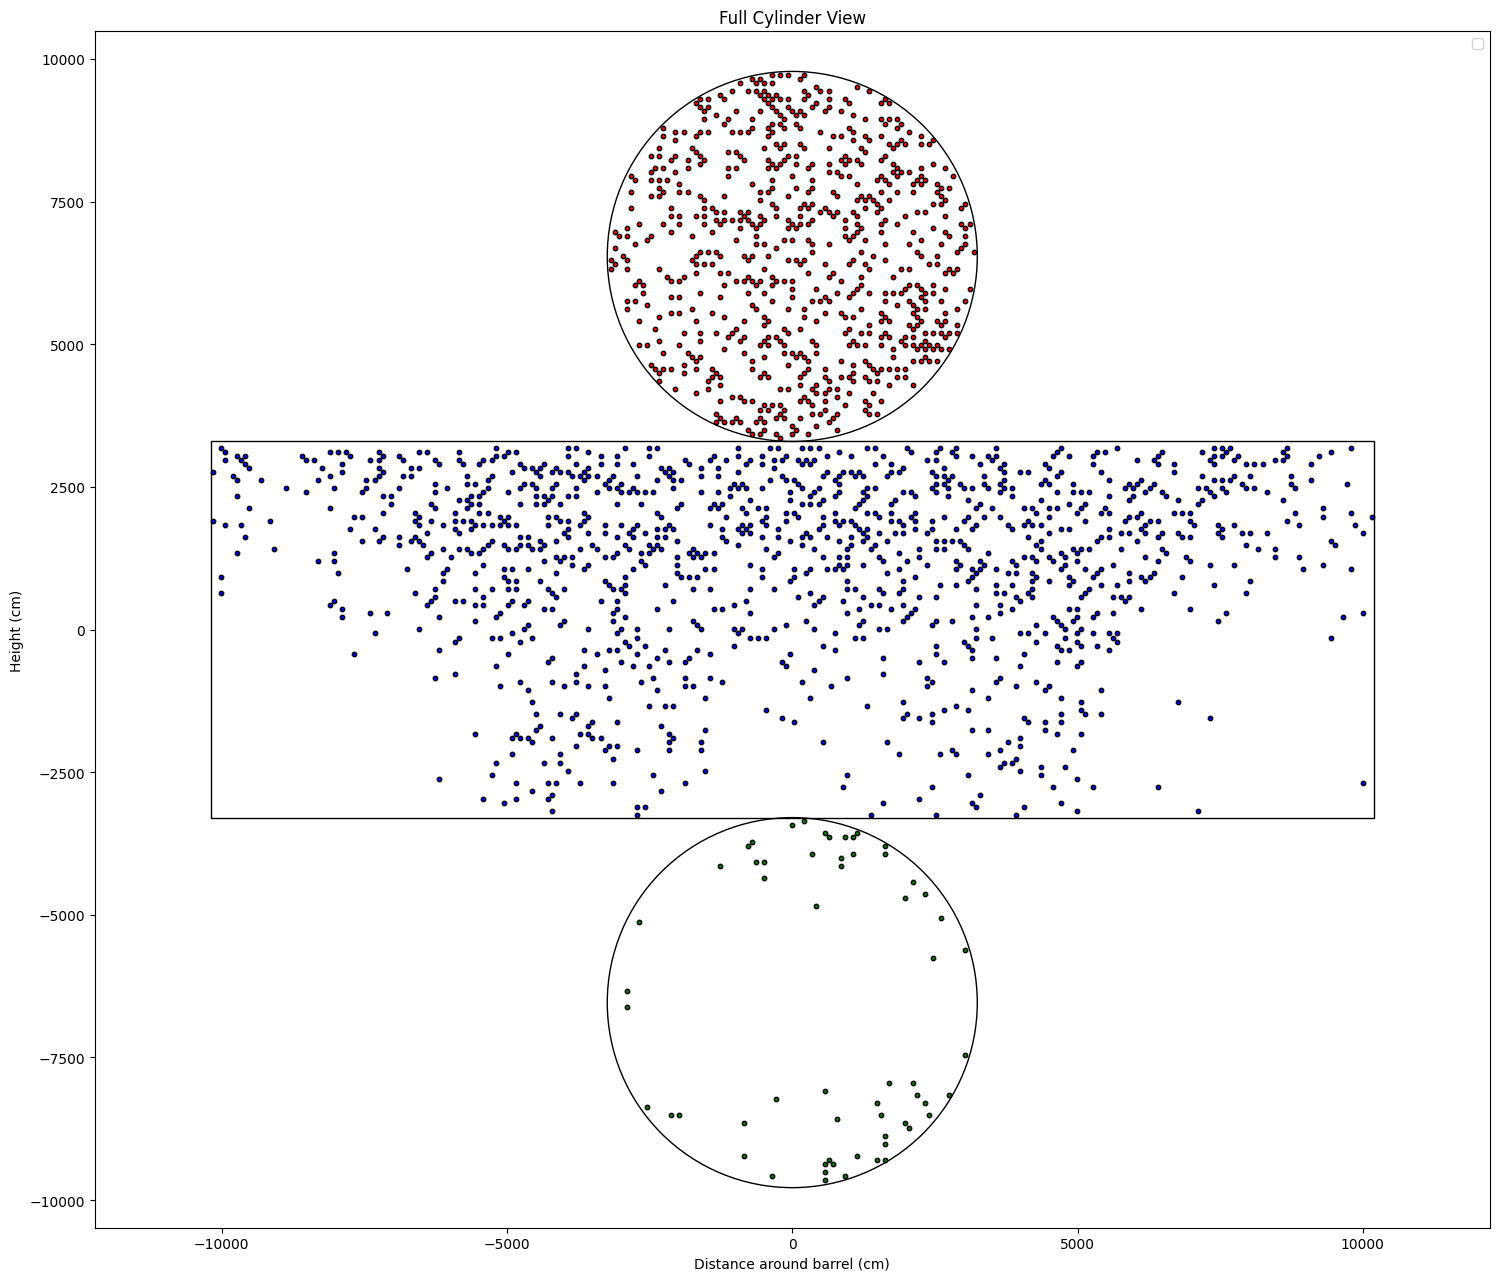

In [23]:
def pmt_2d_projection_pos(pmt_ids):
    fig, ax_barrel = plt.subplots(1, 1, figsize=(18, 18))
    
    # some vars that are globally relevant
    #center_pmt = pmt_ids[0]
    #n = get_pmt_normal(center_pmt)
    #cent_pos = np.array(pmt_dict[center_pmt])
    #cent_x, cent_y, cent_z = cent_pos
    
    # full barrel plot
    rect = Rectangle((-np.pi*radius, -height/2), 2*np.pi*radius, height, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(rect)
    top_circle = Circle((0, height/2 + radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(top_circle)
    bottom_circle = Circle((0, (-height/2)-radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(bottom_circle)
    
    ax_barrel.set_xlim(-1.2*np.pi*radius, 1.2*np.pi*radius)
    ax_barrel.set_ylim(-1.2*radius - height, 1.2*radius + height)
    ax_barrel.set_aspect('equal')
    ax_barrel.set_xlabel("Distance around barrel (cm)")
    ax_barrel.set_ylabel("Height (cm)")
    ax_barrel.set_title("Full Cylinder View")
    
    ax_barrel.legend(loc='upper right')
    
    # red square highlighting region of interest

    for id in pmt_ids:
        pmt_x, pmt_y, pmt_z, type = pmt_dict[id][0], pmt_dict[id][1], pmt_dict[id][2], pmt_dict[id][3]
        if type == 'top':
            color = 'red'
            net_x, net_y = pmt_x, pmt_y + radius + height/2
            
        if type == 'bottom':
            color = 'green'
            net_x, net_y = pmt_x, pmt_y - radius - height/2
            
        if type == 'barrel':
            color = 'blue'
            phi = np.arctan2(pmt_y, pmt_x)
            net_x, net_y = radius * phi, pmt_z

        ax_barrel.scatter(
            net_x, net_y,
            s=10,
            color=color,
            marker = 'o',
            edgecolors='k',
            label=f'Center PMT: {center_pmt}'
        )

all_pmt_ids = pmt_lookup.index.values
positions = pmt_lookup[['posX','posY','posZ']].values

hit_counts = hit_df['pmt_id'].value_counts()

def get_nearest_pmts(pmt_id, k):
    if pmt_id not in pmt_lookup.index:
        raise ValueError(f"PMT {pmt_id} not found")

    target = pmt_lookup.loc[pmt_id].values

    # compute distances
    dists = np.linalg.norm(positions - target, axis=1)
    mask = all_pmt_ids != pmt_id

    nearest_idx = np.argsort(dists[mask])[:k]
    nearest_pmts = all_pmt_ids[mask][nearest_idx]

    return nearest_pmts

#pmt_2d_projection_pos(all_pmt_ids)

# most hit counts
top10_id = hit_df["pmt_id"].value_counts().head(100).index.tolist()

# make column for difference between number of hits and number of incident photons for each pmt
hit_counts = hit_df['pmt_id'].value_counts()
photon_counts = ph_df['tubeId'].value_counts()

diff_counts = (hit_counts - photon_counts)/ (photon_counts)

top_hit_diffs_id = diff_counts.abs().sort_values(ascending=False).head(2000).index.tolist()

pmt_2d_projection_pos(top_hit_diffs_id)





In [ ]:
top_id = hit_df["pmt_id"].value_counts().head(100).index.tolist()


#pmt_2d_projection_pos(top_id)

pmt_2d_projection_po([])

In [ ]:
# histogram of hit_df['time']

plt.hist(hit_df['time'], bins=100, range=(1000, 2000))
plt.xlabel('Time (ns)')